# E-Commerce Sales Analysis

## Project Overview
This project analyzes a Brazilian e-commerce dataset from Olist stores 
containing 100k orders from 2016-2018. 

Objectives:
- Understand customer behaviour
- Analyze order and delivery performance
- Identify geographic trends
- Provide data-driven business recommendations

Datasets Used: Customers, Orders
Tools: Python, Pandas, Matplotlib, Seaborn

## 1.  Importing Libraries

In [ ]:
%pip install "numpy<2"

In [2]:
#importing libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading Customer Data

In [ ]:
#loading customer data as CSV
pd.set_option("display.max_columns", None)
df_customers =pd.read_csv("archive/olist_customers_dataset.csv")

## 3. Customer Data Exploration

In [5]:
#Get the first 5 row of the dataset
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
#total number of row and column
df_customers.shape

(99441, 5)

In [7]:
#describe the dataset
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [8]:
#checking if customer_id appears once per row
# to confirm it represents individual orders not customers
df_customers['customer_id'].value_counts()

06b8999e2fba1a1fbc88172c00ba8bc7    1
c023f30c1147aeb0358474f3b1dbc707    1
b5cbf43f42281920a175fc99650c91d6    1
19f4e983f8f05b7de16670f8a0cf0ac7    1
229ac14c6ee6d6a606264ebcc861beb7    1
                                   ..
31665bd5bc542687ab54c9fd9ed9917b    1
37fb9cce079a4887c96b59bae2011d05    1
1d815f3ad9b2017b6da2c4f1cbb1180b    1
6b05c8f3a25a71005d5eb9b51766c333    1
274fa6071e5e17fe303b9748641082c8    1
Name: customer_id, Length: 99441, dtype: int64

In [9]:
## checking if customer_unique_id appears once per row
# to confirm it represents customers not orders
df_customers['customer_unique_id'].value_counts()

8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
081f07439678af2da7755a0aa572154d     1
9c57789a6a587f4efcfb01e36c106014     1
9e4c21635f640562de1a6976374fba03     1
06c0ea6ee892364d1608ee47aa9f56a0     1
84732c5050c01db9b23e19ba39899398     1
Name: customer_unique_id, Length: 96096, dtype: int64

In [10]:
#getting the total number of unique values for customer_unique_id
df_customers['customer_unique_id'].nunique()

96096

In [11]:
#getting the total number of unique values for customer_id
df_customers['customer_id'].nunique()

99441

## 4. Customer Data Analysis

In [12]:
#create variable for customer_unique_id
total_customer_unique_id = df_customers['customer_unique_id'].nunique()
total_customer_id = df_customers['customer_id'].nunique()

In [14]:
#subtract total number of customer_id from customer_unique_id to get total number of repeat customers.
total_returning_customers = total_customer_id - total_customer_unique_id
print (f"Number of repeat orders from returning customers is {total_returning_customers}")

Number of repeat orders from returning customers is 3345


In [15]:
print(f"Percentage of repeat orders from returning customer is {round((total_returning_customers/total_customer_id) * 100, 2)}")

Percentage of repeat orders from returning customer is 3.36


## 5. Loading Order Dataset

In [16]:
#load order dataset as csv
pd.set_option("display.max_columns", None)
df_orders = pd.read_csv("archive/olist_orders_dataset.csv")

## 6. Order Dataset Exploration

In [17]:
#getting the first 5 row of the data for a start
df_orders.head() 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [18]:
#data info describing the rows in the dataset
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [19]:
#total number of rows and columns
df_orders.shape

(99441, 8)

In [20]:
#checking number of unique values for order_id to understand what it represents
df_orders['order_id'].nunique()

99441

In [22]:
#get value counts for each order status to analyse it
df_orders['order_status'].value_counts()

delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

## 7. Order Dataset Cleaning

In [25]:
#conver datetime columns from object to datetime for analysis
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_approved_at'] = pd.to_datetime(df_orders['order_approved_at'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])
df_orders['order_delivered_carrier_date'] = pd.to_datetime(df_orders['order_delivered_carrier_date'])

In [26]:
#description of each column in the order dataset
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


## 8. Order Dataset  Analysis

In [50]:
#calculate percentage of delivered orders
delivered_orders = df_orders['order_status'].value_counts()['delivered']
total_order = len(df_orders)
print(f"percentage of delivered order is {round((delivered_orders/total_order) * 100, 2)}")

percentage of delivered order is 97.02


In [51]:
#calculate percentage of canceled orders
canceled_orders = df_orders['order_status'].value_counts()['canceled']
total_order = len(df_orders)
print(f"percentage of canceled order is {round((canceled_orders/total_order) * 100, 2)}")

percentage of canceled order is 0.63


In [27]:
#get total number of order purchase for each month in consecutive order to analyse 
#order purchase per month
df_orders['order_purchase_timestamp'].dt.month.value_counts().sort_index()

1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: order_purchase_timestamp, dtype: int64

In [28]:
#get total number of order purchase for each day of week to analyse data
df_orders['order_purchase_timestamp'].dt.day_name().value_counts()

Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Sunday       11960
Saturday     10887
Name: order_purchase_timestamp, dtype: int64

In [29]:
#subtracting order delivery time from order purchase time to get order delivery duration
df_orders['delivery_duration'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days
#get mathematical summary of delivery duration
df_orders['delivery_duration'].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_duration, dtype: float64

In [30]:
#subtracting estimated delivery date from actual delivery date to determine late or early order delivery
df_orders['delivery_before_estimated_days'] = (df_orders['order_estimated_delivery_date'] - df_orders['order_delivered_customer_date']).dt.days
df_orders['delivery_before_estimated_days']

0         7.0
1         5.0
2        17.0
3        12.0
4         9.0
         ... 
99436    10.0
99437     1.0
99438     5.0
99439    20.0
99440    17.0
Name: delivery_before_estimated_days, Length: 99441, dtype: float64

In [31]:
#late delivery
late_delivery = len(df_orders[df_orders['delivery_before_estimated_days'] <0 ])
late_delivery

7827

In [32]:
#early delivery
len(df_orders[df_orders['delivery_before_estimated_days'] > 0 ])

87187

In [52]:
print(f"percentage of late delivery(after estimated date) is {round((late_delivery / total_order) * 100, 2)}")

percentage of late delivery(after estimated date) is 7.87


## Merge Customer and Order Data for Analysis

In [35]:
#create a single dataset for customer and order
df_customer_order = df_customers.merge(df_orders, on = 'customer_id')
df_customer_order

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration,delivery_before_estimated_days
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,8.0,10.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,16.0,7.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,26.0,-2.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,14.0,12.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,11.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,6.0,11.0
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,7.0,8.0
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,30.0,-8.0
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,12.0,18.0


In [54]:
#total number of order from the first ten states with the highest order
df_customer_order['customer_state'].value_counts().head(10)

SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: customer_state, dtype: int64

In [37]:
print(f"percentage of orders from top 3 states {round(((df_customer_order['customer_state'].value_counts().head(3).sum())/total_order) * 100, 2)}")

percentage of orders from top 3 states 66.61


In [38]:
#get averge delivery duration for each states, with the 10 states with longest delivery duration
df_customer_order.groupby(df_customer_order['customer_state'])['delivery_duration'].mean().sort_values(ascending=False).head(10)

customer_state
RR    28.975610
AP    26.731343
AM    25.986207
AL    24.040302
PA    23.316068
MA    21.117155
SE    21.029851
CE    20.817826
AC    20.637500
PB    19.953578
Name: delivery_duration, dtype: float64

## 9. Data Visualization

In [39]:
orders_by_day = df_orders['order_purchase_timestamp'].dt.day_name().value_counts()
orders_by_day

Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Sunday       11960
Saturday     10887
Name: order_purchase_timestamp, dtype: int64

In [40]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day = orders_by_day.reindex(days_order)

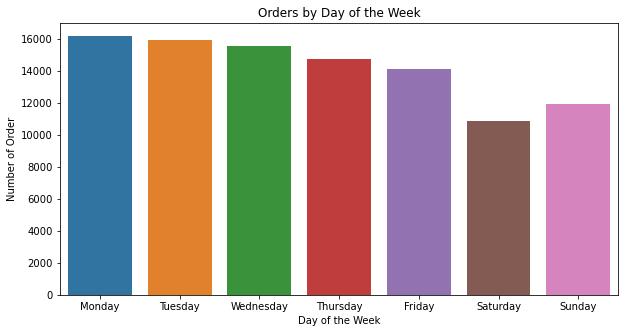

In [41]:
# visualizing orders by day of the week to identify peak shopping days
# helps inform marketing campaign scheduling
plt.figure(figsize=(10, 5))
sns.barplot(x=orders_by_day.index, y=orders_by_day.values)
plt.title('Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Order')
plt.show()

In [42]:
#store monthly orders in variable
orders_by_month = df_orders['order_purchase_timestamp'].dt.month.value_counts().sort_index()
orders_by_month

1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: order_purchase_timestamp, dtype: int64

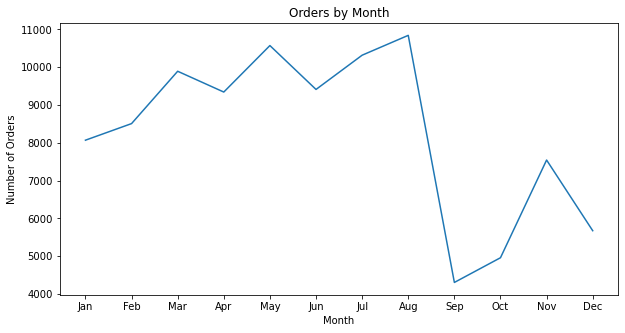

In [43]:
# visualizing orders by month to identify month with highest orders
# helps inform marketing campaign scheduling
plt.figure(figsize=(10, 5))
sns.lineplot(x=orders_by_month.index, y=orders_by_month.values)
plt.title('Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

In [44]:
#store total number of orders from each state in a variable
orders_by_state = df_customer_order['customer_state'].value_counts().head(10)
orders_by_state

SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: customer_state, dtype: int64

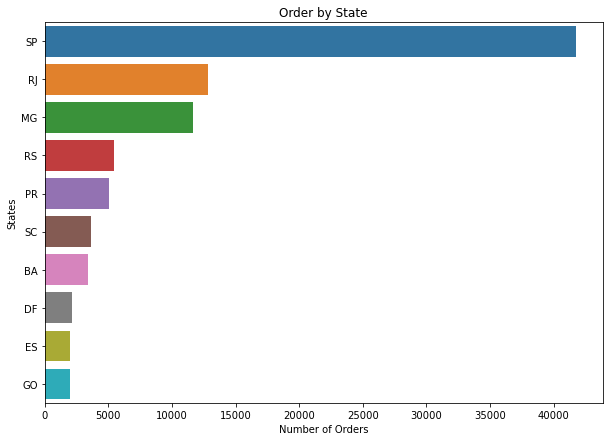

In [45]:
# visualizing orders by region(states) to identify peak shopping states
# helps inform marketing campaign scheduling
plt.figure(figsize=(10,7))
sns.barplot(x=orders_by_state.values, y=orders_by_state.index)
plt.title('Order by State')
plt.xlabel('Number of Orders')
plt.ylabel('States')
plt.show()

In [46]:
#store average delivery duration for each state in variable for analysis
delivery_by_state = df_customer_order.groupby(df_customer_order['customer_state'])['delivery_duration'].mean().sort_values(ascending=False).head(10)
delivery_by_state

customer_state
RR    28.975610
AP    26.731343
AM    25.986207
AL    24.040302
PA    23.316068
MA    21.117155
SE    21.029851
CE    20.817826
AC    20.637500
PB    19.953578
Name: delivery_duration, dtype: float64

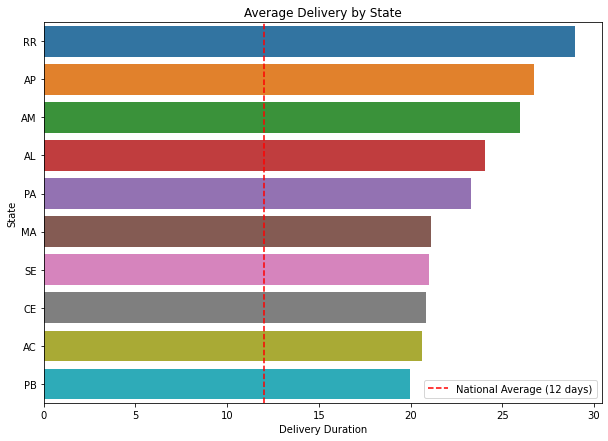

In [47]:
## visualizing average delivery duration for ten states 
# helps inform marketing campaign scheduling
plt.figure(figsize=(10,7))
sns.barplot(x=delivery_by_state.values, y=delivery_by_state.index)
plt.title('Average Delivery by State')
plt.xlabel('Delivery Duration')
plt.ylabel('State')
plt.axvline(x=12, color='red', linestyle='--', label='National Average (12 days)')
plt.legend()
plt.show()

In [48]:
order_status = df_orders['order_status'].value_counts()
order_status
# Filter out delivered
order_status_filtered = order_status[order_status.index != 'delivered']
order_status_filtered

shipped        1107
canceled        625
unavailable     609
invoiced        314
processing      301
created           5
approved          2
Name: order_status, dtype: int64

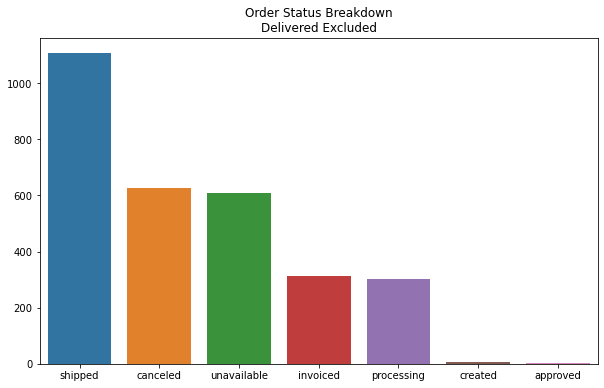

In [49]:
# visualizing orders status breakdown excluding delivered to understand analysis
#for orders not delivered
# helps inform marketing campaign scheduling
plt.figure(figsize=(10, 6))
sns.barplot(x=order_status_filtered.index, y=order_status_filtered.values)
plt.title('Order Status Breakdown\nDelivered Excluded')
plt.xlabel=('Order Status')
plt.ylabel=('Number of Orders')
plt.show()

## E-commerce Sales Analysis- Key Findings

Dataset Overview- Sales Analysis project is an exploration of a Brazillian sales dataset from Olist stores with up to 100k orders, spanning from 2016 to 2018. The dataset includes all sales data from customer details, to order details, product, delivery, location, payment and pricing. The goal of the analysis is to propose business recomnedations from the data insights.

## Customer Data Insights
- Olist stores has a customer database of 96,069, each with their customer_unique_id
- Only 3.36% of Olist stores customers are returning customers with repeat orders.

## Order Data Insights
- Olist stores received a total of 99,441 orders purchased.
- 97.02% of orders were successfully delivered
- 0.63% of orders were canceled.
- The average delivery duration is 12 days
- 7.87% of orders were delivered late after estimated delivery date.

- Olist recorded the highest order purchase in July and August(Mid Year) indicating more revenue which is possibly due to the mid year shopping fair in Brazil.
- In september, there was more than 50% decline in order purchase, throught to October.
- Order purchased increase significantly in November and gradually declined by December.

- Customers purchase more on Mondays and it follows a gradual pace through the week and significantly declines on Weekend.

- 44% of total orders came from SP signalling, a very high demand and customer base in the state.
- SP, RJ and MG were top 3 states with total of 66.61% of orders from there.

## Recommendations
- 66.61% of total orders come from SP, RJ and MG which are Southeast Brazil, hence Olist can decide to open a branch of their stores within the region in order to serve its customer base more efficiently.
- Currently, Olist has a large customer base but most of them are one time customers with only, 3.36% of total customers as return customers. In order to increase the number of return customers, Olist can introduce promo of free delivery for all return customers with terms and conditions.
- To improve sales in September and October, Olist can also give some sales discount.
- Cuurently, delivery duration in Norther stateS like RR, AP, AM take about 28 days. To mitigate that, Olist can consider situating a warehouse within the northern region.
- To boost Saturday deals, Olist can run special weekend promo.
- 